## 1. Importación de librerías

In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


## 2. Carga e inspección inicial de los datos



In [7]:
# 2. CARGA E INSPECCIÓN INICIAL

# 2. CARGA E INSPECCIÓN INICIAL
df = pd.read_csv('/content/ecommerce_sales_1000_records[1].csv')
df['Date'] = pd.to_datetime(df['Date'])


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Estadísticas descriptivas de variables numéricas
df.describe()


,Quantity,Price,Date
count,1000.000000,1000.000000,1000
mean,3.035000,8940.486210,2026-03-31 13:56:38.400000
min,1.000000,407.430000,2026-01-01 00:00:00
25%,2.000000,1738.235000,2026-02-15 00:00:00
50%,3.000000,2962.040000,2026-03-31 00:00:00
75%,4.000000,6263.752500,2026-05-14 00:00:00
max,5.000000,60347.510000,2026-06-29 00:00:00
std,1.402049,14229.456287,NaN


## 3. Análisis Exploratorio de Datos (EDA)

La variable objetivo será Category, correspondiente a una clasificación multiclase.

### 3.1 Distribución de la variable objetivo

,Frecuencia,Porcentaje
Category,,
Electronics,328,32.8
Fashion,226,22.6
Home Appliances,219,21.9
Accessories,161,16.1
Books,66,6.6


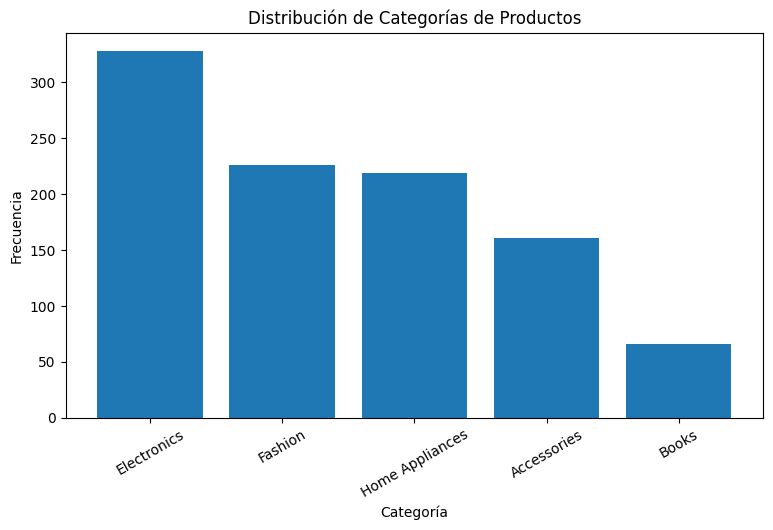

In [9]:
target_counts = df['Category'].value_counts()
target_percent = df['Category'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({
    'Frecuencia': target_counts,
    'Porcentaje': target_percent.round(2)
})
display(summary_target)

plt.figure(figsize=(9, 5))
plt.bar(target_counts.index, target_counts.values)
plt.title('Distribución de Categorías de Productos')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.xticks(rotation=30)
plt.show()


In [10]:
product_category_unique = df.groupby('Product')['Category'].nunique().sort_values(ascending=False)

print("Número de categorías distintas asociadas a cada producto:")
display(product_category_unique)

if product_category_unique.max() == 1:
    print("\nConclusión: cada producto pertenece a una sola categoría.")
    print("Por lo tanto, Product será excluida del entrenamiento para evitar fuga de información.")
else:
    print("\nConclusión: existen productos asociados a más de una categoría.")
    print("Product podría evaluarse como predictor, aunque se debe justificar cuidadosamente.")


Número de categorías distintas asociadas a cada producto:


,Category
Product,
Air Fryer,1
Backpack,1
Book,1
Coffee Maker,1
Headphones,1
Jeans,1
Keyboard,1
Laptop,1
Mixer,1



Conclusión: cada producto pertenece a una sola categoría.
Por lo tanto, Product será excluida del entrenamiento para evitar fuga de información.


### 3.3 Distribución de precio y cantidad por categoría

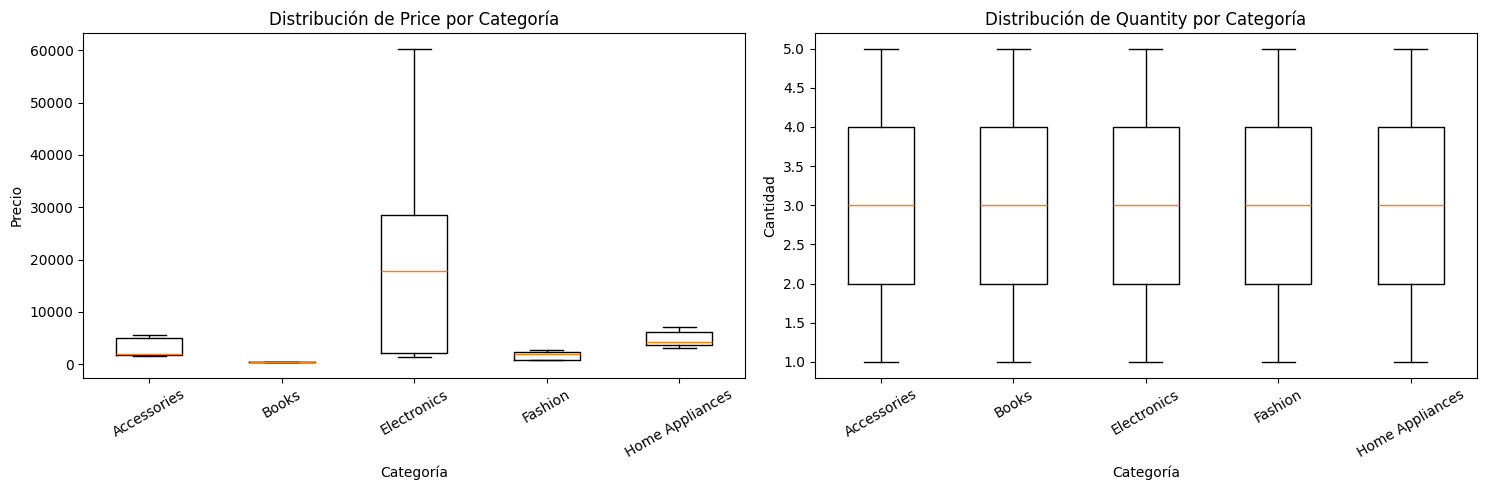

In [11]:
categories = sorted(df['Category'].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

price_data = [df.loc[df['Category'] == cat, 'Price'] for cat in categories]
axes[0].boxplot(price_data, labels=categories)
axes[0].set_title('Distribución de Price por Categoría')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Precio')
axes[0].tick_params(axis='x', rotation=30)

qty_data = [df.loc[df['Category'] == cat, 'Quantity'] for cat in categories]
axes[1].boxplot(qty_data, labels=categories)
axes[1].set_title('Distribución de Quantity por Categoría')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 3.4 Análisis por ciudad y comportamiento temporal

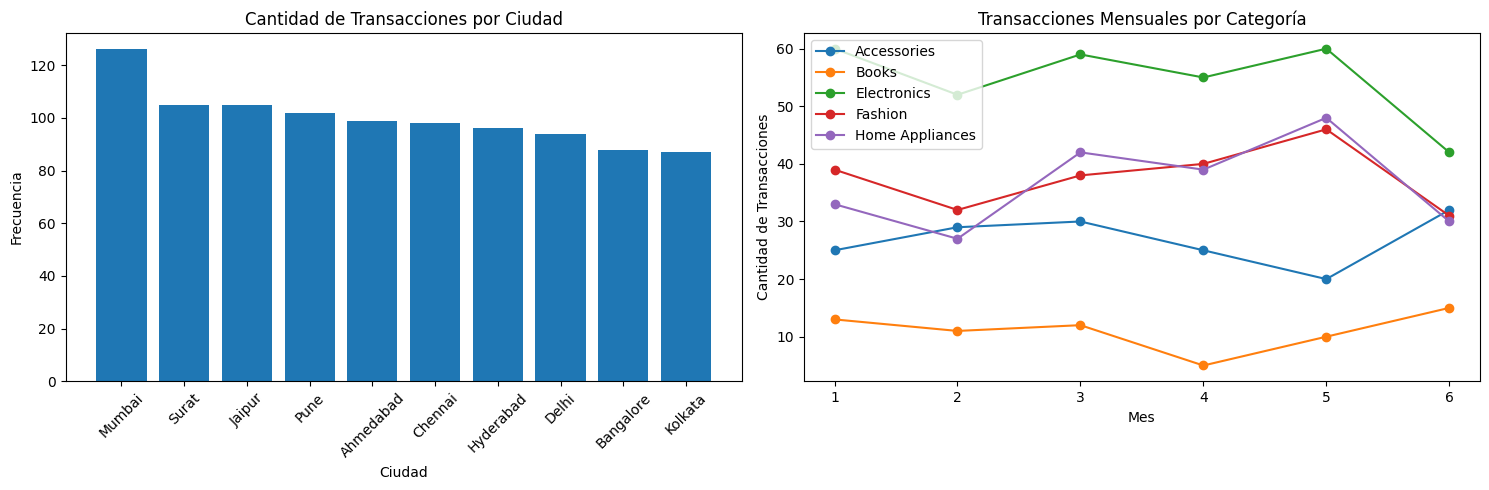

In [ ]:
# 3.4 DISTRIBUCIÓN POR CIUDAD Y MES

df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

city_counts = df['City'].value_counts()
axes[0].bar(city_counts.index, city_counts.values)
axes[0].set_title('Cantidad de Transacciones por Ciudad')
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=45)

monthly_counts = df.groupby(['Month', 'Category']).size().reset_index(name='Count')
for category in sorted(df['Category'].unique()):
    temp = monthly_counts[monthly_counts['Category'] == category]
    axes[1].plot(temp['Month'], temp['Count'], marker='o', label=category)

axes[1].set_title('Transacciones Mensuales por Categoría')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad de Transacciones')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Feature Engineering

Se generan variables temporales desde Date y una transformación logarítmica de Price.  

In [12]:
df_model = df.copy()

# Variables temporales
df_model['Month'] = df_model['Date'].dt.month
df_model['DayOfWeek'] = df_model['Date'].dt.dayofweek
df_model['Quarter'] = df_model['Date'].dt.quarter
df_model['Is_Weekend'] = (df_model['DayOfWeek'] >= 5).astype(int)

df_model['Log_Price'] = np.log1p(df_model['Price'])

print("Variables creadas:")
print(["Month", "DayOfWeek", "Quarter", "Is_Weekend", "Log_Price"])

df_model.head()


Variables creadas:
['Month', 'DayOfWeek', 'Quarter', 'Is_Weekend', 'Log_Price']


,Order_ID,Product,Category,Quantity,Price,City,Date,Month,DayOfWeek,Quarter,Is_Weekend,Log_Price
0,ORD1001,Backpack,Accessories,1,1629.00,Hyderabad,2026-03-04,3,2,1,0,7.396335
1,ORD1002,Keyboard,Electronics,2,1570.94,Surat,2026-01-23,1,4,1,0,7.360066
2,ORD1003,Book,Books,4,407.86,Mumbai,2026-02-25,2,2,1,0,6.013373
3,ORD1004,Keyboard,Electronics,5,1530.61,Surat,2026-02-20,2,4,1,0,7.334075
4,ORD1005,Tablet,Electronics,5,27549.31,Jaipur,2026-05-31,5,6,2,1,10.223769


## 5. Preprocesamiento

Se define Category como variable objetivo.  
Se excluyen Order_ID, Date y Product.

In [13]:
TARGET = 'Category'

features = [
    'Quantity',
    'Price',
    'Log_Price',
    'City',
    'Month',
    'DayOfWeek',
    'Quarter',
    'Is_Weekend'
]

X = df_model[features]
y = df_model[TARGET]

numeric_features = ['Quantity', 'Price', 'Log_Price', 'Month', 'DayOfWeek', 'Quarter', 'Is_Weekend']
categorical_features = ['City']

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Features utilizadas:")
print(features)
print("\nVariable objetivo:")
print(TARGET)
print("\nClases:")
print(sorted(y.unique()))


Features utilizadas:
['Quantity', 'Price', 'Log_Price', 'City', 'Month', 'DayOfWeek', 'Quarter', 'Is_Weekend']

Variable objetivo:
Category

Clases:
['Accessories', 'Books', 'Electronics', 'Fashion', 'Home Appliances']


In [14]:
# División Train/Test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba       : {X_test.shape[0]} registros")

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True).round(3))


Entrenamiento: 800 registros
Prueba       : 200 registros

Distribución en entrenamiento:
Category
Electronics        0.328
Fashion            0.226
Home Appliances    0.219
Accessories        0.161
Books              0.066
Name: proportion, dtype: float64

Distribución en prueba:
Category
Electronics        0.330
Fashion            0.225
Home Appliances    0.220
Accessories        0.160
Books              0.065
Name: proportion, dtype: float64


## 6. Entrenamiento de Modelos

Se entrenan tres modelos de clasificación supervisada:

1. Regresión Logística.
2. Árbol de Decisión.
3. Random Forest.



### 6.1 Regresión Logística

In [16]:
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('classifier', LogisticRegression(
        max_iter=2000,
        C=1.0,
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

print(f"Train Accuracy: {lr_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy : {lr_model.score(X_test, y_test):.4f}")


Train Accuracy: 0.6737
Test Accuracy : 0.6750


### 6.2 Árbol de Decisión

In [17]:
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)
print(f"Train Accuracy: {dt_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy : {dt_model.score(X_test, y_test):.4f}")


Train Accuracy: 0.9062
Test Accuracy : 0.8750


### 6.3 Random Forest

In [18]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)
print(f"Train Accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy : {rf_model.score(X_test, y_test):.4f}")


Train Accuracy: 0.9275
Test Accuracy : 0.8750


In [25]:
# 7. FUNCIÓN DE EVALUACIÓN MULTICLASE

def evaluate_model(name, model, Xtr, Xte, ytr, yte):
    ytr_pred = model.predict(Xtr)
    yte_pred = model.predict(Xte)
    yte_prob = model.predict_proba(Xte)

    classes = model.classes_

    metrics = {
        'Modelo': name,
        'Train Accuracy': accuracy_score(ytr, ytr_pred),
        'Test Accuracy': accuracy_score(yte, yte_pred),
        'Precision Weighted': precision_score(yte, yte_pred, average='weighted', zero_division=0),
        'Recall Weighted': recall_score(yte, yte_pred, average='weighted', zero_division=0),
        'F1 Weighted': f1_score(yte, yte_pred, average='weighted', zero_division=0),
        'ROC-AUC OVR Weighted': roc_auc_score(
            yte,
            yte_prob,
            multi_class='ovr',
            average='weighted',
            labels=classes
        ),
        'Overfitting Gap': accuracy_score(ytr, ytr_pred) - accuracy_score(yte, yte_pred)
    }

    return metrics, yte_pred, yte_prob

models = {
    'Regresión Logística': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

results = []
predictions = {}

for name, model in models.items():
    metrics, y_pred, y_prob = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(metrics)
    predictions[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob
    }

results_df = pd.DataFrame(results)
display(results_df.round(4))


,Modelo,Train Accuracy,Test Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,ROC-AUC OVR Weighted,Overfitting Gap
0,Regresión Logística,0.6738,0.675,0.6791,0.675,0.6423,0.8809,-0.0013
1,Decision Tree,0.9062,0.875,0.8873,0.875,0.8762,0.9836,0.0312
2,Random Forest,0.9275,0.875,0.8889,0.875,0.8769,0.9857,0.0525


### 7.1 Matrices de Confusión

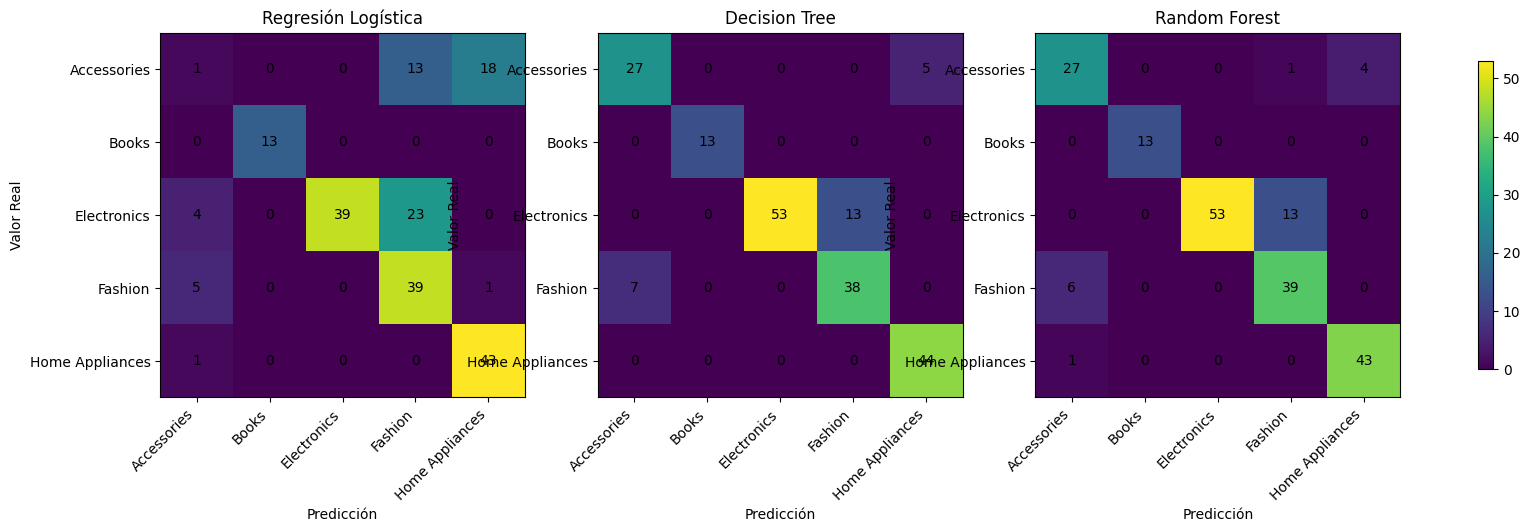

In [20]:
labels = sorted(y.unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = predictions[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    im = ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()


### 7.2 Reporte detallado por clase

In [21]:
# 7.2 CLASSIFICATION REPORT

for name in models.keys():
    print(name)
    print(classification_report(y_test, predictions[name]['y_pred'], zero_division=0))


Regresión Logística
                 precision    recall  f1-score   support

    Accessories       0.09      0.03      0.05        32
          Books       1.00      1.00      1.00        13
    Electronics       1.00      0.59      0.74        66
        Fashion       0.52      0.87      0.65        45
Home Appliances       0.69      0.98      0.81        44

       accuracy                           0.68       200
      macro avg       0.66      0.69      0.65       200
   weighted avg       0.68      0.68      0.64       200

Decision Tree
                 precision    recall  f1-score   support

    Accessories       0.79      0.84      0.82        32
          Books       1.00      1.00      1.00        13
    Electronics       1.00      0.80      0.89        66
        Fashion       0.75      0.84      0.79        45
Home Appliances       0.90      1.00      0.95        44

       accuracy                           0.88       200
      macro avg       0.89      0.90      0.89   

### 7.3 Comparación de métricas y control de overfitting

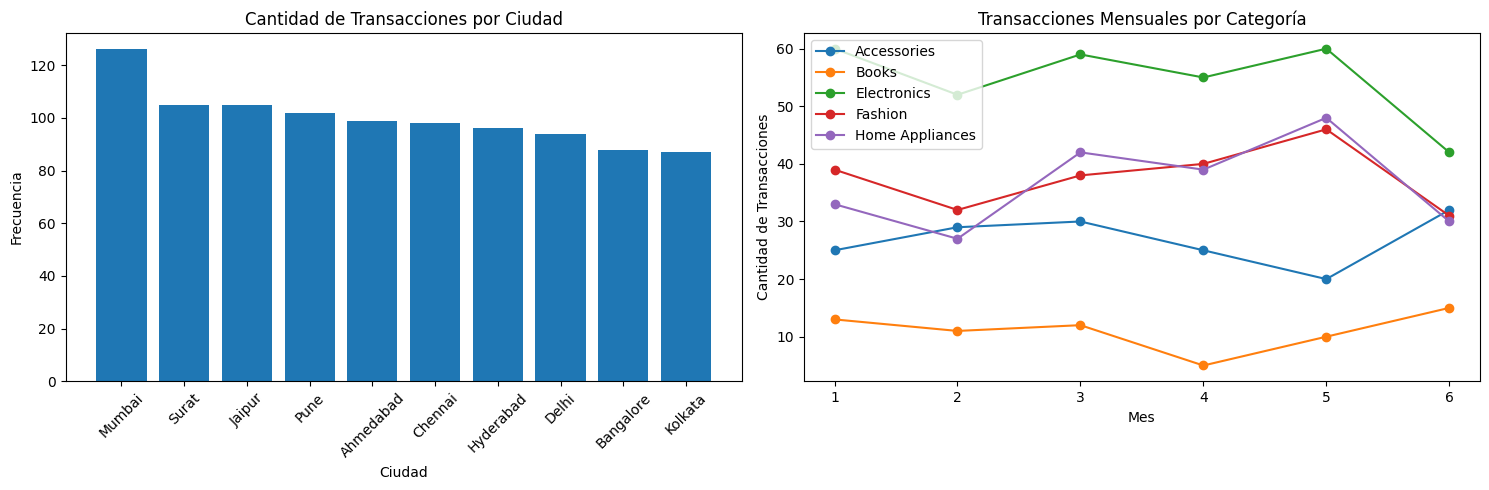

In [22]:
# 3.4 Distribución por ciudad y mes
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

city_counts = df['City'].value_counts()
axes[0].bar(city_counts.index, city_counts.values)
axes[0].set_title('Cantidad de Transacciones por Ciudad')
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=45)

monthly_counts = df.groupby(['Month', 'Category']).size().reset_index(name='Count')
for category in sorted(df['Category'].unique()):
    temp = monthly_counts[monthly_counts['Category'] == category]
    axes[1].plot(temp['Month'], temp['Count'], marker='o', label=category)

axes[1].set_title('Transacciones Mensuales por Categoría')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad de Transacciones')
axes[1].legend()

plt.tight_layout()
plt.show()


### 7.4 Importancia de características — Random Forest

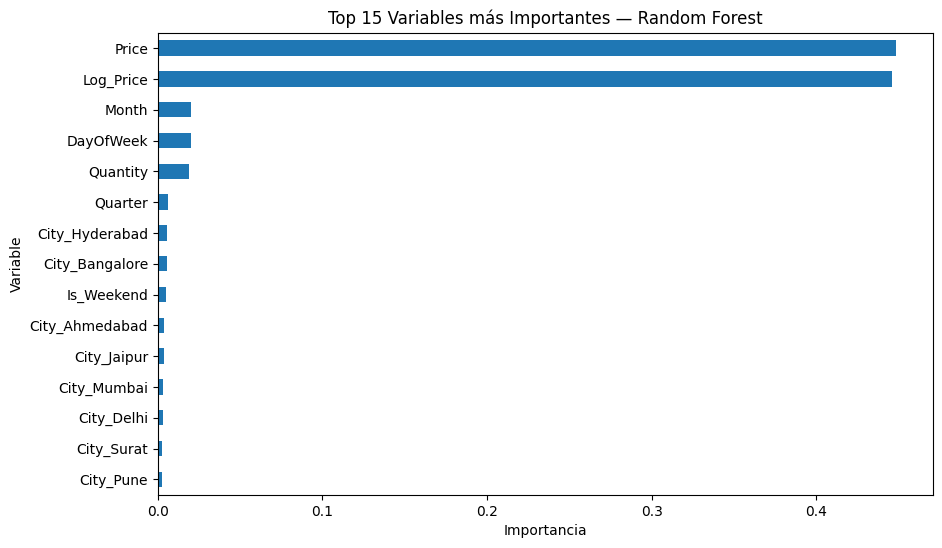

,0
Price,0.4484
Log_Price,0.4460
Month,0.0201
DayOfWeek,0.0200
Quantity,0.0191
Quarter,0.0064
City_Hyderabad,0.0056
City_Bangalore,0.0054
Is_Weekend,0.0052
City_Ahmedabad,0.0038


In [23]:
# 7.4 IMPORTANCIA DE VARIABLES EN RANDOM FOREST

rf_classifier = rf_model.named_steps['classifier']
preprocessor = rf_model.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

feat_imp = pd.Series(rf_classifier.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Variables más Importantes — Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

display(feat_imp.head(15).round(4))


### 7.5 Validación cruzada

In [24]:
# 7.5 VALIDACIÓN CRUZADA

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_weighted'
    )
    cv_results[name] = {
        'F1 Weighted CV Mean': scores.mean(),
        'F1 Weighted CV Std': scores.std()
    }

cv_df = pd.DataFrame(cv_results).T
display(cv_df.round(4))


,F1 Weighted CV Mean,F1 Weighted CV Std
Regresión Logística,0.6283,0.0246
Decision Tree,0.9011,0.0170
Random Forest,0.8718,0.0197
